# KNN & Decision Trees
### Machine Learning BSCS-2, BSDS-2
#### 2/03/2026

**Lab Overview**

| # | Section | Key Concepts |
|---|---------|-------------|
| 1 | Datasets | Binary, multi-class, non-linear |
| 2 | Distance metrics | Euclidean, Manhattan, Minkowski |
| 3 | KNN from scratch | Lazy learning, majority vote |
| 4 | KNN decision boundaries | Effect of K on boundaries |
| 5 | Choosing K | Cross-validation, bias-variance trade-off |
| 6 | Multi-class KNN | Extending to 3+ classes, confusion matrix |
| 7 | Impurity Measures | Gini, Entropy, Information Gain |
| 8 | Decision Tree from Scratch | CART algorithm, recursive splitting |
| 9 | DT Boundaries | Effect of max depth |
| 10 | KNN vs Decision Tree | Side-by-side comparison |
| 11 | Scikit-learn |  real-world datasets |
| 12| Exercises | 5 hands-on challenges |


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import Counter

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
%matplotlib inline

## 1. Generating datasets

We are to create three datasets with increasing difficulty;

| Dataset | Classes | Separability | Challenge for |
|---------|---------|-------------|---------------|
| Binary clusters | 2 | Linear | Neither |
| Multi-class | 3 | Cluster-based | Linear models |
| Concentric circles | 2 | Non-linear | Linear models |


In [2]:
def generate_binary_dataset(n=200):
    n_half = n // 2
    X0 = np.random.randn(n_half, 2) + np.array([1, 1])
    X1 = np.random.randn(n_half, 2) + np.array([4, 4])
    X = np.vstack([X0, X1])
    y = np.array([0]*n_half + [1]*n_half)
    return X, y

In [3]:
def generate_multiclass_dataset(n=300):
    n_per = n // 3
    X0 = np.random.randn(n_per, 2) * 0.8 + np.array([0, 3])
    X1 = np.random.randn(n_per, 2) * 0.8 + np.array([3, 0])
    X2 = np.random.randn(n_per, 2) * 0.8 + np.array([-3, 0])
    X = np.vstack([X0, X1, X2])
    y = np.array([0]*n_per + [1]*n_per + [2]*n_per)
    return X, y

In [6]:
def generate_nonlinear_dataset(n=300):
    X, y = make_circles(n_samples=n, noise=0.1, factor=0.4, random_state=42)
    return X, y

In [7]:
X_binary, y_binary = generate_binary_dataset()
X_multi, y_multi = generate_multiclass_dataset()
X_circles, y_circles = generate_nonlinear_dataset()

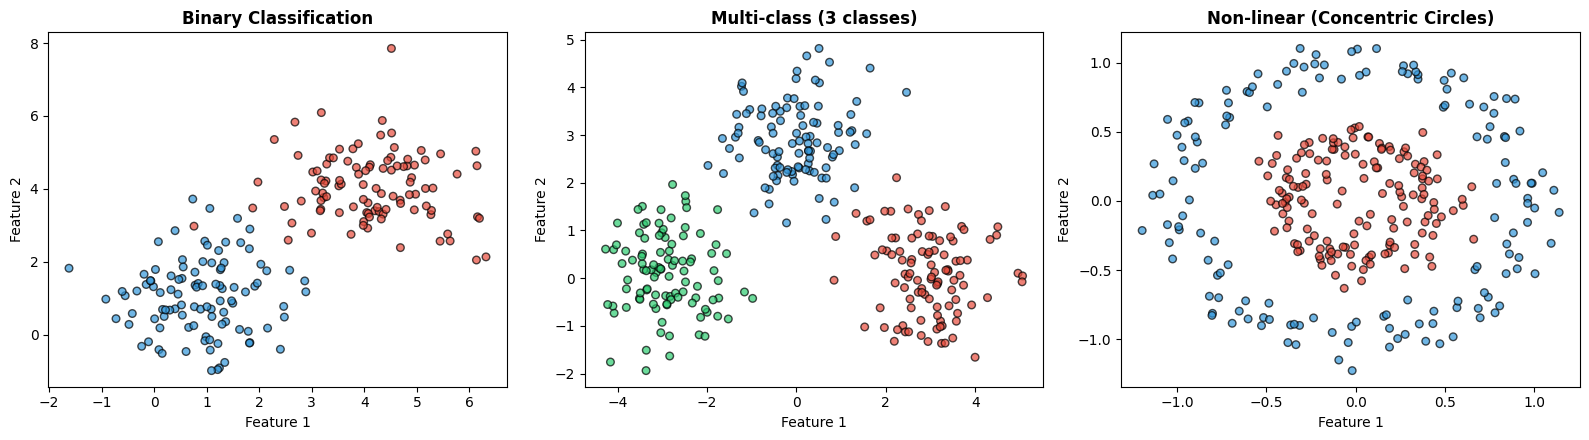

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cmap2 = ListedColormap(['#3498db', '#e74c3c'])
cmap3 = ListedColormap(['#3498db', '#e74c3c', '#2ecc71'])

axes[0].scatter(X_binary[:, 0], X_binary[:, 1], c=y_binary, cmap=cmap2, edgecolors='k', s=30, alpha=0.7)
axes[0].set_title("Binary Classification", fontweight='bold')
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi, cmap=cmap3, edgecolors='k', s=30, alpha=0.7)
axes[1].set_title("Multi-class (3 classes)", fontweight='bold')
axes[1].set_xlabel("Feature 1"); axes[1].set_ylabel("Feature 2")

axes[2].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap=cmap2, edgecolors='k', s=30, alpha=0.7)
axes[2].set_title("Non-linear (Concentric Circles)", fontweight='bold')
axes[2].set_xlabel("Feature 1"); axes[2].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## 2. Distance Metrics

### The Minkowski Family

$$d(\mathbf{a}, \mathbf{b}) = \left( \sum_{i=1}^{n} |a_i - b_i|^p \right)^{1/p}$$

| $p$ | Name | Geometric Shape | When to Use |
|-----|------|----------------|-------------|
| 1 | Manhattan (L1) | Diamond | Features on different scales |
| 2 | Euclidean (L2) | Circle | Default choice, continuous features |
| $\infty$ | Chebyshev (L∞) | Square | When max deviation matters |


In [9]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

def minkowski_distance(a, b, p):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

In [ ]:

p1 = np.array([1, 2])
p2 = np.array([4, 6])

print(f"Point A: {p1}")
print(f"Point B: {p2}")
print(f"Euclidean distance (L2): {euclidean_distance(p1, p2):.4f}")
print(f"Manhattan distance (L1): {manhattan_distance(p1, p2):.4f}")

print(f"Minkowski(p=3): {minkowski_distance(p1, p2, 3):.4f}") ##
print(f"Minkowski(p=1): {minkowski_distance(p1, p2, 1):.4f}") ## M
print(f"Minkowski(p=2): {minkowski_distance(p1, p2, 2):.4f}") ## E

Point A: [1 2]
Point B: [4 6]
Euclidean distance (L2): 5.0000
Manhattan distance (L1): 7.0000
Minkowski(p=3): 4.4979
Minkowski(p=1): 7.0000
Minkowski(p=2): 5.0000


### Unit circles under each metric

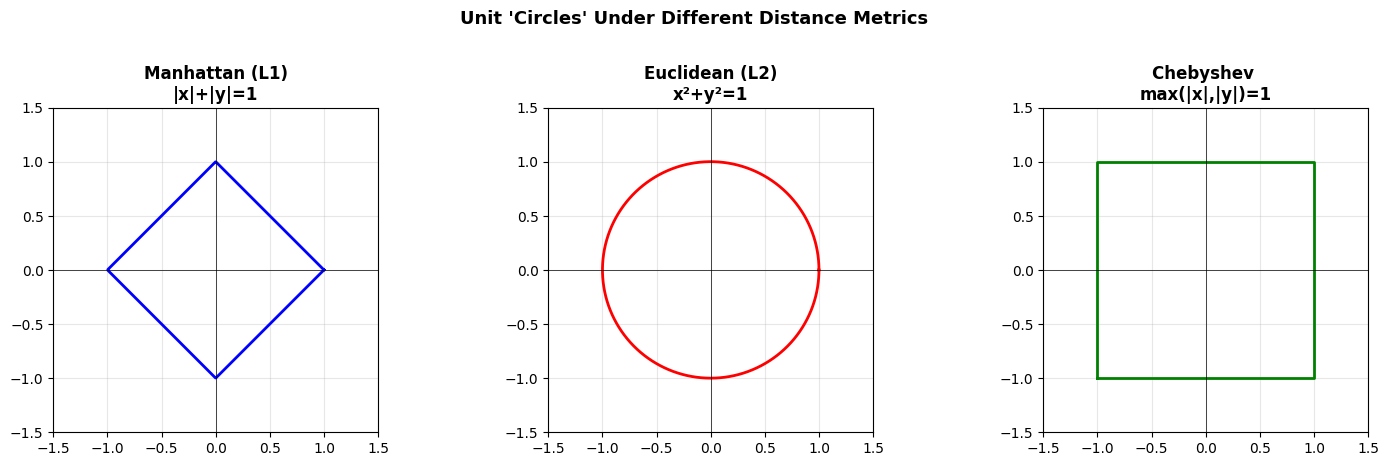

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
theta = np.linspace(0, 2 * np.pi, 1000)

l1_x = np.cos(theta); l1_y = np.sin(theta)
l1_norm = np.abs(l1_x) + np.abs(l1_y)
l1_x /= l1_norm; l1_y /= l1_norm

l2_x = np.cos(theta); l2_y = np.sin(theta)

linf_pts = np.array([[-1,-1],[-1,1],[1,1],[1,-1],[-1,-1]])

axes[0].plot(l1_x, l1_y, 'b-', linewidth=2)
axes[0].set_title("Manhattan (L1)\n|x|+|y|=1", fontweight='bold')
axes[0].set_xlim(-1.5, 1.5); axes[0].set_ylim(-1.5, 1.5)
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='k', linewidth=0.5); axes[0].axvline(0, color='k', linewidth=0.5)

axes[1].plot(l2_x, l2_y, 'r-', linewidth=2)
axes[1].set_title("Euclidean (L2)\nx²+y²=1", fontweight='bold')
axes[1].set_xlim(-1.5, 1.5); axes[1].set_ylim(-1.5, 1.5)
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='k', linewidth=0.5); axes[1].axvline(0, color='k', linewidth=0.5)

axes[2].plot(linf_pts[:,0], linf_pts[:,1], 'g-', linewidth=2)
axes[2].set_title("Chebyshev \nmax(|x|,|y|)=1", fontweight='bold')
axes[2].set_xlim(-1.5, 1.5); axes[2].set_ylim(-1.5, 1.5)
axes[2].set_aspect('equal'); axes[2].grid(True, alpha=0.3)
axes[2].axhline(0, color='k', linewidth=0.5); axes[2].axvline(0, color='k', linewidth=0.5)

plt.suptitle("Unit 'Circles' Under Different Distance Metrics", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
query = np.array([2.5, 2.5])
dists_euc = np.array([euclidean_distance(query, x) for x in X_binary[:10]])
dists_man = np.array([manhattan_distance(query, x) for x in X_binary[:10]])

print(f"Distance from query point {query} to first 10 training points:")
print(f"{'Point':<18} {'Euclidean':<12} {'Manhattan':<12} {'Label'}")

for i in range(10):
    print(f"({X_binary[i,0]:5.2f}, {X_binary[i,1]:5.2f})    {dists_euc[i]:<12.4f} {dists_man[i]:<12.4f} {y_binary[i]}")

Distance from query point [2.5 2.5] to first 10 training points:
Point              Euclidean    Manhattan    Label
( 1.50,  0.86)    1.9211       2.6416       0
( 1.65,  2.52)    0.8526       0.8753       0
( 0.77,  0.77)    2.4525       3.4683       0
( 2.58,  1.77)    0.7368       0.8118       0
( 0.53,  1.54)    2.1899       2.9269       0
( 0.54,  0.53)    2.7783       3.9291       0
( 1.24, -0.91)    3.6377       4.6713       0
(-0.72,  0.44)    3.8279       5.2872       0
(-0.01,  1.31)    2.7785       3.6986       0
( 0.09, -0.41)    3.7789       5.3203       0


## KNN
### Algorithm pseudocode

1. Stores all training examples (no model is "trained")
2. For a new query point $\mathbf{x}_q$:
   - Compute distance $d(\mathbf{x}_q, \mathbf{x}_i)$ to every training point
   - Sort distances and pick the $K$ smallest
   - Majority vote among those $K$ neighbours results into the predicted class

$$\hat{y} = \text{mode}\{y_i : i \in \mathcal{N}_K(\mathbf{x}_q)\}$$

where $\mathcal{N}_K(\mathbf{x}_q)$ is the set of $K$ nearest neighbours.


In [18]:
class KNearestNeighbours:
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
    
    def _compute_distance(self, a, b):
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((a - b) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(a - b))
        elif self.distance_metric == 'minkowski':
            return np.sum(np.abs(a - b) ** 3) ** (1/3)
    
    def fit(self, X, y):
        self.X_train = X.copy()
        self.y_train = y.copy()
        self.classes_ = np.unique(y)
        print(f"Stored {len(X)} training samples, classes: {self.classes_}, K={self.k}")
    
    def _predict_single(self, x):
        distances = np.array([self._compute_distance(x, x_train) 
                              for x_train in self.X_train])
        k_indices = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_indices]
        vote_counts = Counter(k_labels)
        return vote_counts.most_common(1)[0][0]
    
    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])
    
    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42)

knn = KNearestNeighbours(k=5, distance_metric='euclidean')
knn.fit(X_train, y_train)
print(f"Training accuracy: {knn.accuracy(X_train, y_train)*100:.1f}%")
print(f"Test accuracy: {knn.accuracy(X_test, y_test)*100:.1f}%")

Stored 160 training samples, classes: [0 1], K=5
Training accuracy: 99.4%
Test accuracy:     100.0%


> these accuracies are high because the two clusters are well separated.

- tracing  the algorithm.

In [25]:
query_point = X_test[0]
distances = np.array([euclidean_distance(query_point, x) for x in X_train])
k_idx = np.argsort(distances)[:5]

print(f"Query point: ({query_point[0]:.2f}, {query_point[1]:.2f})")
print(f"True label:  {y_test[0]}")
for rank, idx in enumerate(k_idx):
    print(f" Neighbour {rank+1}: ({X_train[idx,0]:.2f}, {X_train[idx,1]:.2f}), "
          f"dist={distances[idx]:.3f}, label={y_train[idx]}")
votes = Counter(y_train[k_idx])
print(f"Votes: {dict(votes)} -> Predicted class: {votes.most_common(1)[0][0]}")

Query point: (0.55, 1.86)
True label:  0
 Neighbour 1: (0.54, 2.06), dist=0.201, label=0
 Neighbour 2: (0.78, 1.71), dist=0.265, label=0
 Neighbour 3: (0.53, 1.54), dist=0.315, label=0
 Neighbour 4: (0.32, 1.61), dist=0.336, label=0
 Neighbour 5: (0.47, 1.51), dist=0.353, label=0
Votes: {0: 5} -> Predicted class: 0


## 4. KNN Decision boundaries

|Small K | Large K|
|---|--|
Jagged boundary| Smooth boundary|
Sensitive to noise(over fitting)| may miss local patterns(under fitting)

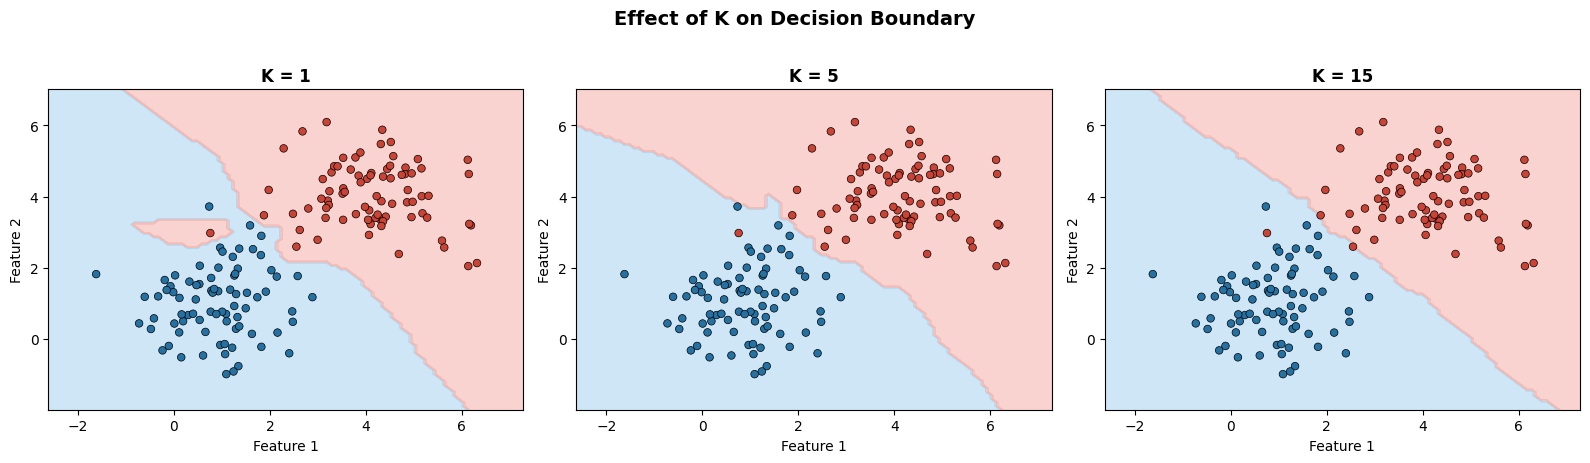

In [28]:
def plot_knn_boundary(X_train, y_train, k, ax, title, n_classes=2):
    cmap_bg = ListedColormap(['#AED6F1', '#F5B7B1', '#ABEBC6'][:n_classes])
    cmap_pts = ListedColormap(['#2471A3', '#CB4335', '#239B56'][:n_classes])
    
    margin = 1
    x_min, x_max = X_train[:, 0].min() - margin, X_train[:, 0].max() + margin
    y_min, y_max = X_train[:, 1].min() - margin, X_train[:, 1].max() + margin
    h = 0.1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    model = KNearestNeighbours(k=k)
    model.X_train = X_train.copy(); model.y_train = y_train.copy()
    model.classes_ = np.unique(y_train)
    Z = model.predict(grid_points).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_pts, 
               edgecolors='k', s=30, linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, k_val in zip(axes, [1, 5, 15]):
    plot_knn_boundary(X_train, y_train, k_val, ax, f"K = {k_val}")
plt.suptitle("Effect of K on Decision Boundary", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Choosing K

- the bias variance trade off
k = 1
k = N

-> k that somewhere in between 1 - N (cross-validation)


In [40]:
k_values = list(range(1, 26))
train_accuracies = []
test_accuracies = []

In [41]:
for k in k_values:
    model = KNearestNeighbours(k=k)
    model.X_train = X_train.copy(); model.y_train = y_train.copy()
    model.classes_ = np.unique(y_train)
    train_accuracies.append(model.accuracy(X_train, y_train))
    test_accuracies.append(model.accuracy(X_test, y_test))

In [42]:
best_k = k_values[np.argmax(test_accuracies)]
print(f"Best K: {best_k} => {max(test_accuracies)*100:.1f}%")

Best K: 3 => 100.0%


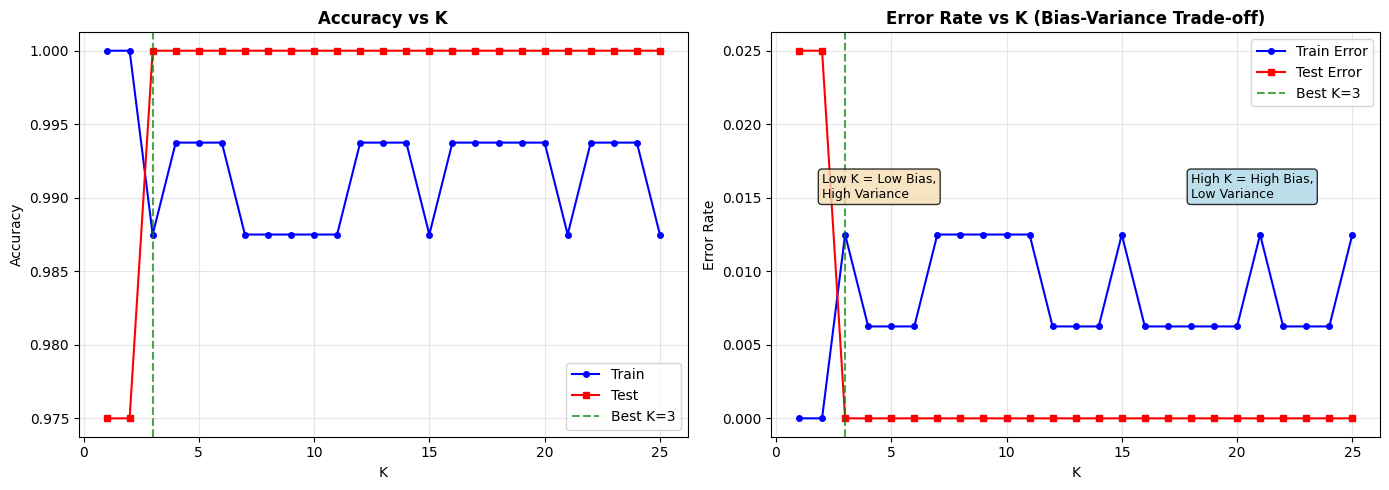

In [43]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, train_accuracies, 'b-o', markersize=4, label='Train')
axes[0].plot(k_values, test_accuracies, 'r-s', markersize=4, label='Test')
axes[0].axvline(best_k, color='green', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
axes[0].set_xlabel("K"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs K", fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, [1-a for a in train_accuracies], 'b-o', markersize=4, label='Train Error')
axes[1].plot(k_values, [1-a for a in test_accuracies], 'r-s', markersize=4, label='Test Error')
axes[1].axvline(best_k, color='green', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
axes[1].set_xlabel("K"); axes[1].set_ylabel("Error Rate")
axes[1].set_title("Error Rate vs K (Bias-Variance Trade-off)", fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].annotate("Low K = Low Bias,\nHigh Variance", xy=(2, 0.015), fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[1].annotate("High K = High Bias,\nLow Variance", xy=(18, 0.015), fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
plt.tight_layout()
plt.show()

## 6. Multi-class classification with KNN


In [46]:
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42)

knn_multi = KNearestNeighbours(k=5)
knn_multi.fit(X_m_train, y_m_train)
print(f"3-class test accuracy: {knn_multi.accuracy(X_m_test, y_m_test)*100:.1f}%")

preds = knn_multi.predict(X_m_test)
n_classes = 3
cm = np.zeros((n_classes, n_classes), dtype=int)
for true, pred in zip(y_m_test, preds):
    cm[true, pred] += 1

print(f"\nConfusion Matrix:")
print(f"{'':>12} Pred 0   Pred 1   Pred 2")
for i in range(n_classes):
    print(f"  Actual {i}:  {cm[i,0]:5d}    {cm[i,1]:5d}    {cm[i,2]:5d}")

print()
for cls in range(n_classes):
    tp = cm[cls, cls]
    fp = cm[:, cls].sum() - tp
    fn = cm[cls, :].sum() - tp
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"  Class {cls}: Precision={prec:.2f}, Recall={rec:.2f}")

Stored 210 training samples, classes: [0 1 2], K=5
3-class test accuracy: 100.0%

Confusion Matrix:
             Pred 0   Pred 1   Pred 2
  Actual 0:     35        0        0
  Actual 1:      0       28        0
  Actual 2:      0        0       27

  Class 0: Precision=1.00, Recall=1.00
  Class 1: Precision=1.00, Recall=1.00
  Class 2: Precision=1.00, Recall=1.00


Circles dataset test accuracy: 100.0%


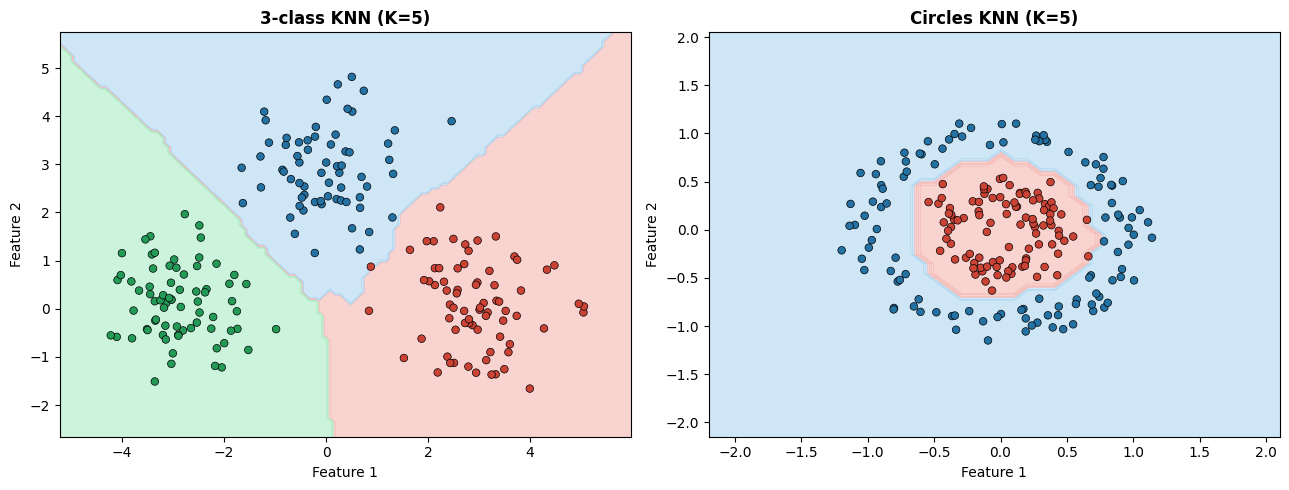

In [47]:
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_circles, y_circles, test_size=0.3, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_knn_boundary(X_m_train, y_m_train, 5, axes[0], "3-class KNN (K=5)", n_classes=3)
plot_knn_boundary(X_c_train, y_c_train, 5, axes[1], "Circles KNN (K=5)", n_classes=2)

knn_circles = KNearestNeighbours(k=5)
knn_circles.X_train = X_c_train; knn_circles.y_train = y_c_train; knn_circles.classes_ = np.unique(y_c_train)
print(f"Circles dataset test accuracy: {knn_circles.accuracy(X_c_test, y_c_test)*100:.1f}%")
plt.tight_layout()
plt.show()

## 7. Decision Trees
- i) Gini Impurity <br />
- ii) Entropy (Information gain) <br />
- iii) Information Gain <br />


In [50]:
def gini_impurity(labels):
    if len(labels) == 0:
        return 0
    counts = Counter(labels)
    total = len(labels)
    return 1 - sum((c / total) ** 2 for c in counts.values())

def entropy(labels):
    if len(labels) == 0:
        return 0
    counts = Counter(labels)
    total = len(labels)
    return -sum((c / total) * np.log2(c / total) for c in counts.values() if c > 0)

def information_gain(parent, left_child, right_child, criterion='gini'):
    measure = gini_impurity if criterion == 'gini' else entropy
    p = len(left_child) / len(parent)
    return measure(parent) - p * measure(left_child) - (1 - p) * measure(right_child)

examples = {
    "Pure [A,A,A,A]":       [0, 0, 0, 0],
    "Balanced [A,A,B,B]":   [0, 0, 1, 1],
    "Skewed [A,A,A,B]":     [0, 0, 0, 1],
    "3-class [A,B,C,C]":    [0, 1, 2, 2],
    "3-class even [A,B,C]": [0, 1, 2],
}

print(f"{'Distribution':<25} {'Gini':<10} {'Entropy':<10}")
for name, labels in examples.items():
    print(f"{name:<25} {gini_impurity(labels):<10.4f} {entropy(labels):<10.4f}")

Distribution              Gini       Entropy   
Pure [A,A,A,A]            0.0000     -0.0000   
Balanced [A,A,B,B]        0.5000     1.0000    
Skewed [A,A,A,B]          0.3750     0.8113    
3-class [A,B,C,C]         0.6250     1.5000    
3-class even [A,B,C]      0.6667     1.5850    


### Gini vs Entropy for Binary Classification

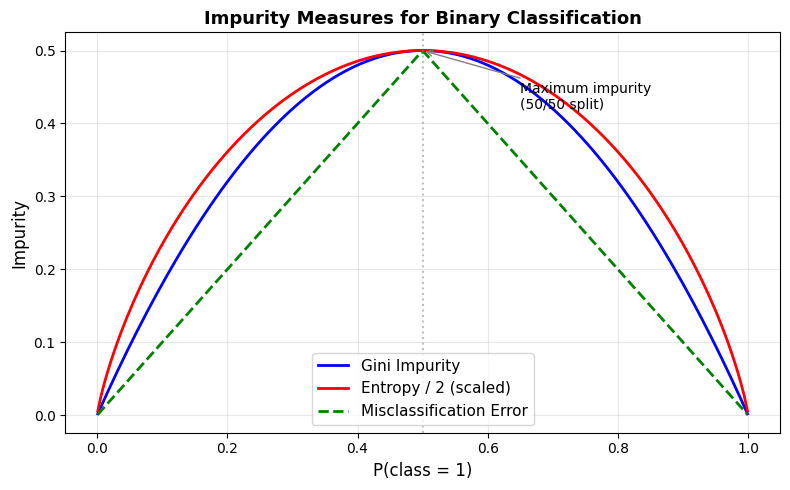

In [49]:
p_range = np.linspace(0.001, 0.999, 200)
gini_vals = 1 - p_range**2 - (1 - p_range)**2
entropy_vals = -p_range * np.log2(p_range) - (1 - p_range) * np.log2(1 - p_range)
misclass_vals = 1 - np.maximum(p_range, 1 - p_range)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_range, gini_vals, 'b-', linewidth=2, label='Gini Impurity')
ax.plot(p_range, entropy_vals / 2, 'r-', linewidth=2, label='Entropy / 2 (scaled)')
ax.plot(p_range, misclass_vals, 'g--', linewidth=2, label='Misclassification Error')
ax.set_xlabel("P(class = 1)", fontsize=12); ax.set_ylabel("Impurity", fontsize=12)
ax.set_title("Impurity Measures for Binary Classification", fontweight='bold', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.annotate("Maximum impurity\n(50/50 split)", xy=(0.5, 0.5), xytext=(0.65, 0.42),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
plt.tight_layout()
plt.show()

## 8. Decision Tree from scratch

### Algorithm pseudocode

1. For each feature $j$ and threshold $t$:
   - Split data into left ($x_j \leq t$) and right ($x_j > t$)
   - Compute weighted impurity reduction (information gain)
2. Pick the $(j, t)$ pair that maximises the gain
3. Recursively split left and right children
4. Stop when, max depth reached, node is pure, or too few samples


In [51]:
class DecisionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTreeClassifier:
    def __init__(self, max_depth=5, min_samples_split=2, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
    
    def _impurity(self, labels):
        if self.criterion == 'gini':
            return gini_impurity(labels)
        return entropy(labels)
    
    def _best_split(self, X, y):
        best_gain = -1
        best_feature, best_threshold = None, None
        parent_impurity = self._impurity(y)
        n = len(y)
        
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for thresh in thresholds:
                left_mask = X[:, feature] <= thresh
                right_mask = ~left_mask
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                
                p_left = left_mask.sum() / n
                weighted_imp = (p_left * self._impurity(y[left_mask]) + 
                               (1 - p_left) * self._impurity(y[right_mask]))
                gain = parent_impurity - weighted_imp
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = thresh
        return best_feature, best_threshold, best_gain
    
    def _build_tree(self, X, y, depth=0):
        n_classes = len(np.unique(y))
        if depth >= self.max_depth or n_classes == 1 or len(y) < self.min_samples_split:
            return DecisionTreeNode(value=Counter(y).most_common(1)[0][0])
        
        feature, threshold, gain = self._best_split(X, y)
        if gain <= 0:
            return DecisionTreeNode(value=Counter(y).most_common(1)[0][0])
        
        left_mask = X[:, feature] <= threshold
        left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        return DecisionTreeNode(feature=feature, threshold=threshold, left=left, right=right)
    
    def fit(self, X, y):
        self.tree_ = self._build_tree(X, y)
    
    def _predict_single(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_single(x, node.left)
        return self._predict_single(x, node.right)
    
    def predict(self, X):
        return np.array([self._predict_single(x, self.tree_) for x in X])
    
    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)
    
    def print_tree(self, node=None, depth=0, prefix="Root"):
        if node is None:
            node = self.tree_
        if node.value is not None:
            print(f"{'  ' * depth}{prefix} → Class {node.value}")
        else:
            print(f"{'  ' * depth}{prefix}: Feature {node.feature} <= {node.threshold:.3f}")
            self.print_tree(node.left, depth + 1, "L")
            self.print_tree(node.right, depth + 1, "R")

In [53]:
decision_tree = DecisionTreeClassifier(max_depth=4, criterion='gini')
decision_tree.fit(X_train, y_train)

print(f"Training accuracy: {decision_tree.accuracy(X_train, y_train)*100:.1f}%")
print(f"Test accuracy: {decision_tree.accuracy(X_test, y_test)*100:.1f}%")

Training accuracy: 100.0%
Test accuracy: 100.0%


In [55]:
def plot_dt_boundary(X_train, y_train, max_depth, ax, title, n_classes=2):
    cmap_bg = ListedColormap(['#AED6F1', '#F5B7B1', '#ABEBC6'][:n_classes])
    cmap_pts = ListedColormap(['#2471A3', '#CB4335', '#239B56'][:n_classes])
    
    margin = 1
    x_min, x_max = X_train[:, 0].min() - margin, X_train[:, 0].max() + margin
    y_min, y_max = X_train[:, 1].min() - margin, X_train[:, 1].max() + margin
    h = 0.1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    model = DecisionTreeClassifier(max_depth=max_depth)
    model.fit(X_train, y_train)
    Z = model.predict(grid_points).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_pts, 
               edgecolors='k', s=30, linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

## 10. KNN vs Decision Tree Comparison

| Property | KNN | Decision Tree |
|----------|-----|---------------|
| Training speed | Instant (just stores data) | Slower (builds tree) |
| Prediction speed | Slow (computes all distances) | Fast (traverse tree) |
| Boundary shape | Smooth, non-linear | Axis-aligned rectangles |
| Feature scaling | Required | Not needed |
| Handles missing data | No | Yes |


Dataset            KNN (K=5)       DT (depth=5)   
Binary Clusters    100.0           100.0          
Multi-class        100.0           98.9           
Circles            100.0           100.0          


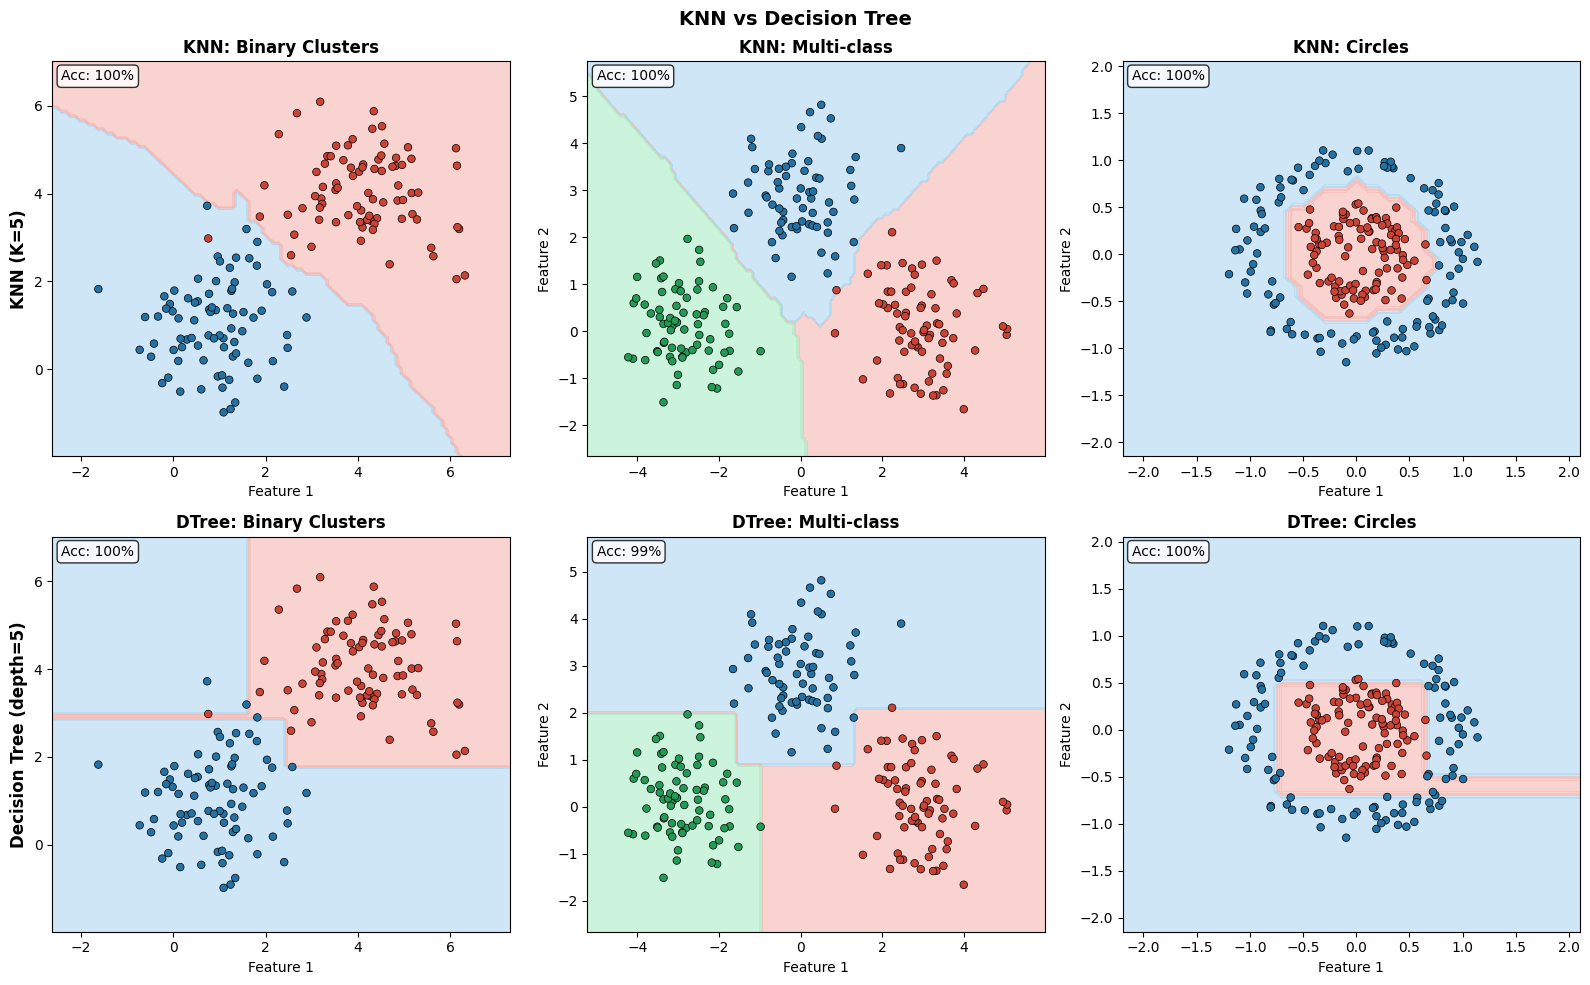

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

datasets = [
    ("Binary Clusters", X_train, y_train, X_test, y_test, 2),
    ("Multi-class", X_m_train, y_m_train, X_m_test, y_m_test, 3),
    ("Circles", X_c_train, y_c_train, X_c_test, y_c_test, 2),
]

print(f"{'Dataset':<18} {'KNN (K=5)':<15} {'DT (depth=5)':<15}")

for col, (name, Xtr, ytr, Xte, yte, nc) in enumerate(datasets):
    plot_knn_boundary(Xtr, ytr, 5, axes[0, col], f"KNN: {name}", n_classes=nc)
    knn_m = KNearestNeighbours(k=5)
    knn_m.X_train = Xtr; knn_m.y_train = ytr; knn_m.classes_ = np.unique(ytr)
    knn_acc = knn_m.accuracy(Xte, yte)
    
    plot_dt_boundary(Xtr, ytr, 5, axes[1, col], f"DTree: {name}", n_classes=nc)
    dt_m = DecisionTreeClassifier(max_depth=5)
    dt_m.fit(Xtr, ytr)
    dt_acc = dt_m.accuracy(Xte, yte)
    
    print(f"{name:<18} {knn_acc*100:<15.1f} {dt_acc*100:<15.1f}")
    
    axes[0, col].text(0.02, 0.98, f"Acc: {knn_acc*100:.0f}%", transform=axes[0, col].transAxes,
                      va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    axes[1, col].text(0.02, 0.98, f"Acc: {dt_acc*100:.0f}%", transform=axes[1, col].transAxes,
                      va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0, 0].set_ylabel("KNN (K=5)", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Decision Tree (depth=5)", fontsize=12, fontweight='bold')
plt.suptitle("KNN vs Decision Tree", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Using real world datasets
### Student trials
